# Urine Data Analysis

After completing the obese cohort data analysis, the realization of needing to see how these lab values behave in normal BMI cohort came. Afterall, control is a thing, right? The same analysis will be performed but including everyone, particularly adults with BMI between and including 16 and 50. 

The BMI cutoffs are as follows:
 * less than 18 kg/m^2: underweight
 * 18-24.9 kg/m^2: normal weight
 * 25-29.9 kg/m^2: overweight
 * 30-39.9 kg/m^2: obese
 * greater than 40 kg/m^2: morbidly obese

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
current_directory = os.getcwd()
print(current_directory)

C:\Users\Rachel\Documents\Github\portfolio_ds_projects\NHANES_analysis


In [3]:
import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

In [4]:
df_d = pd.read_csv('cleaned_demographics.csv')
df_a = pd.read_csv('cleaned_anthropometry.csv')
df_cr = pd.read_csv('urine_cr_alb.csv')

In [5]:
df_d.head()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty
0,109263.0,1.0,2.0,6.0,NaN,NaN,4.66
1,109264.0,2.0,13.0,1.0,NaN,NaN,0.83
2,109265.0,1.0,2.0,3.0,NaN,NaN,3.06
3,109266.0,2.0,29.0,6.0,5.0,3.0,5.00
4,109269.0,1.0,2.0,2.0,NaN,NaN,0.96


In [6]:
adults = df_d[df_d['age_year'] >= 18]

In [7]:
df_a = df_a.dropna(subset=['bmi'])

In [8]:
df_a.isna().sum()

participant_id                 0
weight_kg                      0
weight_comment             12601
recumbent_length_cm        12571
standing_height                0
standing_height_comment    13038
bmi                            0
bmi_category_child          8388
upper_leg_cm                2177
upper_arm_cm                 460
arm_circumference_cm         461
waist_circ_cm                603
hip_circ_cm                 3296
dtype: int64

In [9]:
df_a = df_a.drop(['recumbent_length_cm','bmi_category_child','weight_comment'], axis = 1)

In [10]:
adults_joined = adults.merge(df_a, on='participant_id')

In [11]:
adults_joined['bmi'].describe()

count    8790.000000
mean       29.883413
std         7.603916
min        14.200000
25%        24.700000
50%        28.600000
75%        33.600000
max        92.300000
Name: bmi, dtype: float64

In [12]:
adults_filtered = adults_joined[adults_joined['bmi'] <= 50].copy()

In [13]:
adults_filtered['bmi'].describe()

count    8622.000000
mean       29.357237
std         6.583851
min        14.200000
25%        24.600000
50%        28.500000
75%        33.300000
max        50.000000
Name: bmi, dtype: float64

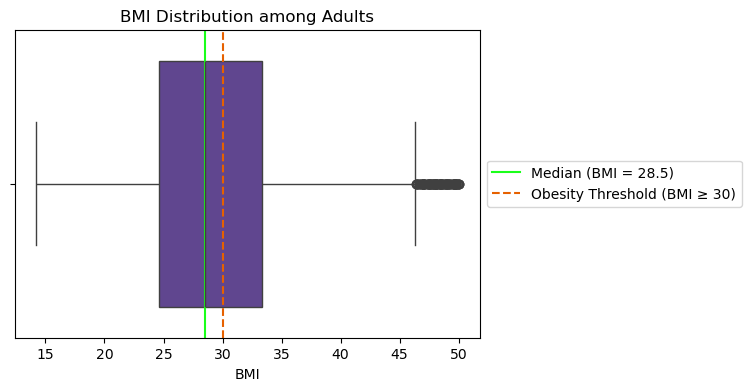

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x='bmi', data=adults_filtered, color = '#5D3A9B')

# Calculate median
median_val = adults_filtered['bmi'].median()

# Add vertical line for the median and include it in the legend
plt.axvline(median_val, color='#1AFF1A', linestyle='-', label=f"Median (BMI = {median_val:.1f})")

# Obesity threshold line
plt.axvline(30, color='#E66100', linestyle='--', label="Obesity Threshold (BMI ≥ 30)")

plt.title("BMI Distribution among Adults")
plt.xlabel("BMI")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

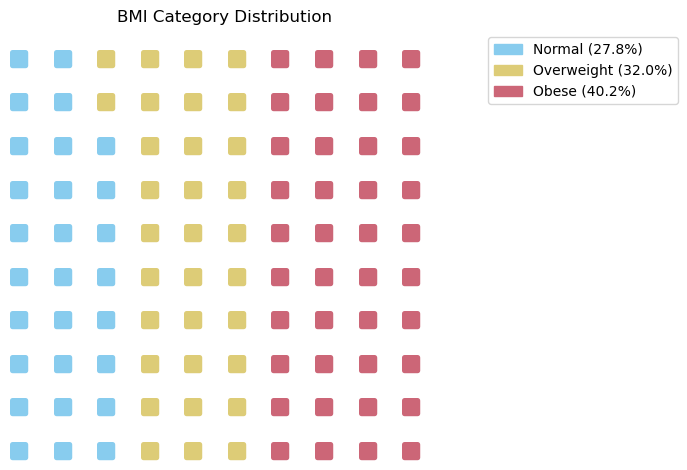

In [15]:
from pywaffle import Waffle

# Create BMI categories
adults_filtered['bmi_category'] = pd.cut(adults_filtered['bmi'], 
                            bins=[0, 25, 30, adults_filtered['bmi'].max()],
                            labels=['Normal', 'Overweight', 'Obese'])

# Count categories
bmi_counts = adults_filtered['bmi_category'].value_counts(normalize=True) * 100

desired_order = ['Normal', 'Overweight', 'Obese']
bmi_counts = bmi_counts.reindex(desired_order)

fig = plt.figure(
    FigureClass=Waffle, 
    rows=10, 
    values=bmi_counts,
    colors=["#88CCEE", "#DDCC77", "#CC6677"],
    title={'label': 'BMI Category Distribution', 'loc': 'center'},
    labels=[f"{cat} ({val:.1f}%)" for cat, val in bmi_counts.items()],
    legend={'loc': 'upper left', 'bbox_to_anchor': (1.1, 1)},
    icons='square',
    icon_size=15
)
plt.show()

Over 70% of the subjects is in the overweight and above range in terms of their BMI.

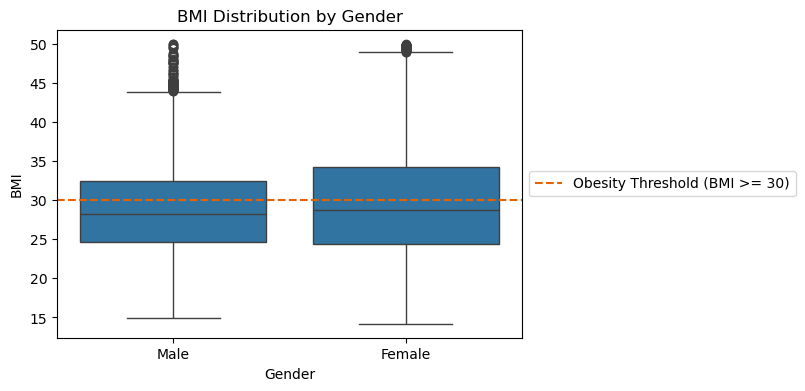

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x='gender',y='bmi',data=adults_filtered)

plt.axhline(30, color='#E66100',linestyle='--', label= "Obesity Threshold (BMI >= 30)")
plt.title("BMI Distribution by Gender")
plt.ylabel('BMI')
plt.xlabel('Gender')
plt.xticks([0,1], ["Male" , "Female"])
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

In [17]:
gender = adults_filtered.groupby('gender')['bmi'].describe()
gender = gender.rename(index={1: "Male", 2:"Female"})
gender

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
Male,4225.0,28.956615,5.970412,14.9,24.7,28.2,32.4,50.0
Female,4397.0,29.742188,7.103129,14.2,24.4,28.8,34.2,50.0


The average BMI for women is higher compared to men. Women's bodies do need more fat for proper hormone regulation so it does make sense. The number of males and females in this dataset is about even.

## Urine Albumin

The first urine lab value that will be analyzed against the BMI is the urine albumin. The urine creatinine and albumin tests are conducted as spot test, not as total excretion over 24 hours. 

For the assay conducted by NHANES lab, the unusual albumin values designated “< LOD” or > 1000 µg/mL are flagged for attention. The expected range is reported by multiple studies but for the purposes of the NHANES data, I decided to use what was reported based on NHANES dataset which is normal range should be <30 mcg/mL (Jones CA, Francis ME, Eberhardt MS, et al. Microalbuminuria in the US Population: Third National Health and Nutrition and Examination Survey. Am L Kidney Dis 2002;39: 445-459.)

To make the analysis and evaluation clearer, only the columns reflecting these units will be kept.

In [18]:
df_cralb = pd.read_csv('urine_cr_alb.csv')

In [19]:
urine_cralb = adults_filtered.merge(df_cralb, on='participant_id')

In [20]:
urine_cralb.head()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty,weight_kg,standing_height,standing_height_comment,...,bmi_category,Unnamed: 0,albumin_urine_ug_mL,albumin_urine_mg_L,alb_comment,creatinine_urine_mg_dL,creatinine_urine_umol_L,creatinine_comment,alb_creat_ratio,collection_year
0,109266.0,2.0,29.0,6.0,5.0,3.0,5.00,97.1,160.2,NaN,...,Obese,1,5.5,5.5,0.0,36.0,3182.4,0.0,15.28,2017-2020
1,109271.0,1.0,49.0,3.0,2.0,3.0,NaN,98.8,182.3,NaN,...,Overweight,3,2.4,2.4,0.0,32.0,2828.8,0.0,7.50,2017-2020
2,109273.0,1.0,36.0,3.0,4.0,3.0,0.83,74.3,184.2,NaN,...,Normal,4,4.9,4.9,0.0,121.0,10696.4,0.0,4.05,2017-2020
3,109274.0,1.0,68.0,7.0,4.0,3.0,1.20,103.7,185.3,NaN,...,Obese,5,12.8,12.8,0.0,120.0,10608.0,0.0,10.67,2017-2020
4,109282.0,1.0,76.0,3.0,5.0,1.0,3.61,83.3,177.1,NaN,...,Overweight,10,16.0,16.0,0.0,192.0,16972.8,0.0,8.33,2017-2020


In [21]:
urine_cralb.shape

(8450, 26)

In [22]:
urine_cralb.columns

Index(['participant_id', 'gender', 'age_year', 'race', 'education_level',
       'marital_status', 'family_income_poverty', 'weight_kg',
       'standing_height', 'standing_height_comment', 'bmi', 'upper_leg_cm',
       'upper_arm_cm', 'arm_circumference_cm', 'waist_circ_cm', 'hip_circ_cm',
       'bmi_category', 'Unnamed: 0', 'albumin_urine_ug_mL',
       'albumin_urine_mg_L', 'alb_comment', 'creatinine_urine_mg_dL',
       'creatinine_urine_umol_L', 'creatinine_comment', 'alb_creat_ratio',
       'collection_year'],
      dtype='object')

In [23]:
urine_cralb = urine_cralb[['participant_id','gender','age_year','race','bmi',
'albumin_urine_ug_mL', 'creatinine_urine_mg_dL','alb_creat_ratio']]

In [24]:
urine_cralb.isna().sum()

participant_id            0
gender                    0
age_year                  0
race                      0
bmi                       0
albumin_urine_ug_mL       0
creatinine_urine_mg_dL    1
alb_creat_ratio           1
dtype: int64

With the initial data cleaning, the NaN values have been removed. 

In [25]:
urine_cralb.describe()

,participant_id,gender,age_year,race,bmi,albumin_urine_ug_mL,creatinine_urine_mg_dL,alb_creat_ratio
count,8450.000000,8450.000000,8450.000000,8450.000000,8450.000000,8450.000000,8449.000000,8449.000000
mean,117114.195148,1.509349,49.318580,3.477870,29.372107,49.307434,131.262635,48.256303
std,4499.043056,0.499942,18.357545,1.581583,6.592660,315.395734,86.976089,337.620871
min,109266.000000,1.000000,18.000000,1.000000,14.200000,0.210000,6.000000,0.270000
25%,113233.750000,1.000000,33.000000,3.000000,24.600000,4.700000,66.000000,4.840000
50%,117081.500000,2.000000,50.000000,3.000000,28.500000,9.100000,115.000000,7.530000
75%,121052.750000,2.000000,64.000000,4.000000,33.300000,18.975000,178.000000,14.560000
max,124822.000000,2.000000,80.000000,7.000000,50.000000,14040.000000,739.000000,11676.920000


In [26]:
urine_alb = urine_cralb[['participant_id','gender','age_year','bmi','albumin_urine_ug_mL', 'race']]

In [27]:
urine_alb['albumin_urine_ug_mL'].describe()

count     8450.000000
mean        49.307434
std        315.395734
min          0.210000
25%          4.700000
50%          9.100000
75%         18.975000
max      14040.000000
Name: albumin_urine_ug_mL, dtype: float64

Although the range of the urine albumin can be a bit ambiguous, values that are significantly above 1000 mcg/mL seems to be too extreme. The data was visualized to see how the distribution appears.

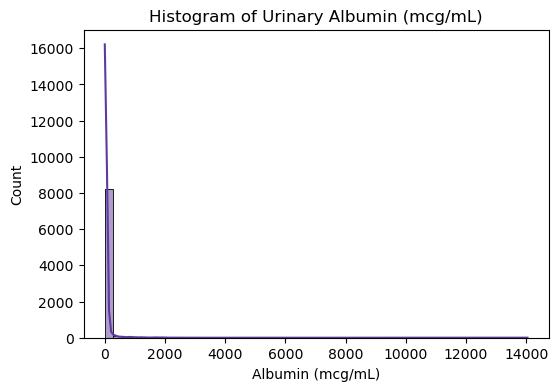

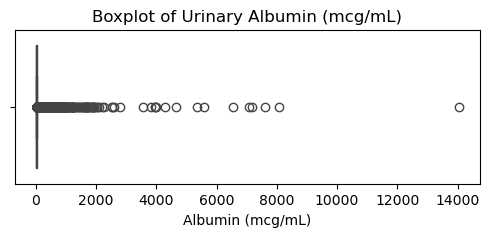

In [28]:
# Histogram
plt.figure(figsize=(6,4))
sns.histplot(urine_alb['albumin_urine_ug_mL'], bins=50, kde=True, color='#5D3A9B')
plt.title("Histogram of Urinary Albumin (mcg/mL)")
plt.xlabel("Albumin (mcg/mL)")
plt.ylabel("Count")
plt.show()

# Boxplot
plt.figure(figsize=(6,2))
sns.boxplot(x=urine_alb['albumin_urine_ug_mL'], color='#E66100')
plt.title("Boxplot of Urinary Albumin (mcg/mL)")
plt.xlabel("Albumin (mcg/mL)")
plt.show()

Because the urine albumin range can be a bit arbitrary, dropping of outliers may not be the best route. However, the 14,000 value should be removed since that is unlikely that the urine albumin level would be that high in the clinical setting. 

The question that arises with this level of albumin is, what is the health status of these subjects? Are they higher in the BMI range than other subjects that have more "reasonable" albumin range? 

In [29]:
urine_alb = urine_alb[urine_alb['albumin_urine_ug_mL'] != 14040]

In [30]:
# Define your threshold
threshold = 1000  

# Count how many subjects exceed the threshold
extreme_count = (urine_alb['albumin_urine_ug_mL'] >= threshold).sum()

# Total number of subjects
total_count = urine_alb['albumin_urine_ug_mL'].notna().sum()

# Percentage
extreme_percent = (extreme_count / total_count) * 100

print(f"Subjects with extreme albumin values (≥ {threshold} µg/mL): {extreme_count}")
print(f"Total subjects with albumin values: {total_count}")
print(f"Percentage extreme: {extreme_percent:.2f}%")


Subjects with extreme albumin values (≥ 1000 µg/mL): 77
Total subjects with albumin values: 8449
Percentage extreme: 0.91%


Although the albumin values are not inherently critical at an elevated level, values above 1000 mcg/mL are highly unusual. As we can see, only 1.25% (43 out of 3447) of the subjects have this extreme value above 1000 mcg/mL. The decision was made to remove these subjects to have a more representative dataset for analysis. 

In [31]:
# Define threshold
threshold = 1000  

# Keep only subjects below threshold
urine_alb_clean = urine_alb[urine_alb['albumin_urine_ug_mL'] < threshold].copy()

print(f"Original: {urine_alb.shape[0]} rows")
print(f"After removing extreme albumin values: {urine_alb_clean.shape[0]} rows")


Original: 8449 rows
After removing extreme albumin values: 8372 rows


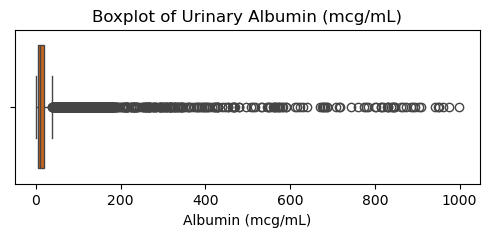

In [32]:
plt.figure(figsize=(6,2))
sns.boxplot(x=urine_alb_clean['albumin_urine_ug_mL'], color='#E66100')
plt.title("Boxplot of Urinary Albumin (mcg/mL)")
plt.xlabel("Albumin (mcg/mL)")
plt.show()

In [33]:
urine_alb_clean.describe()

,participant_id,gender,age_year,bmi,albumin_urine_ug_mL,race
count,8372.000000,8372.000000,8372.000000,8372.000000,8372.000000,8372.000000
mean,117117.560678,1.510511,49.240683,29.346034,27.356524,3.475991
std,4495.372425,0.499919,18.367309,6.585228,78.809699,1.580484
min,109266.000000,1.000000,18.000000,14.200000,0.210000,1.000000
25%,113241.750000,1.000000,33.000000,24.600000,4.600000,3.000000
50%,117098.000000,2.000000,50.000000,28.400000,9.000000,3.000000
75%,121048.250000,2.000000,64.000000,33.300000,18.400000,4.000000
max,124822.000000,2.000000,80.000000,50.000000,998.000000,7.000000


With the outliers removed, the average value of the urine albumin is 31 mcg/mL which is about the reference range from the NHANES study. 

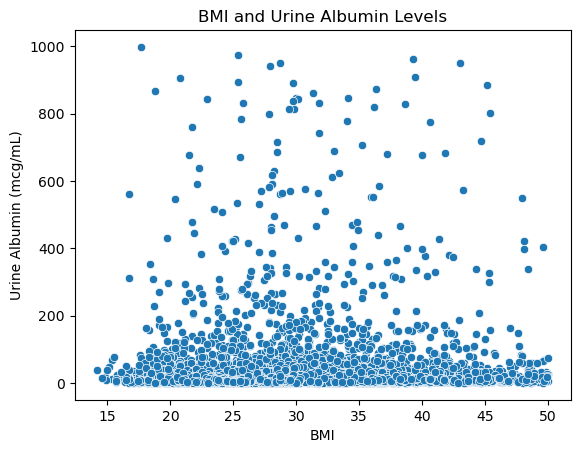

In [34]:
sns.scatterplot(x='bmi',y='albumin_urine_ug_mL',data=urine_alb_clean)
plt.xlabel('BMI')
plt.ylabel('Urine Albumin (mcg/mL)')
plt.title('BMI and Urine Albumin Levels')
plt.show()

<Axes: xlabel='bmi', ylabel='albumin_urine_ug_mL'>

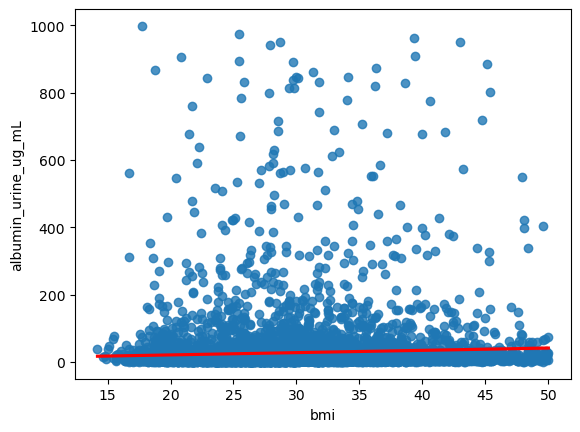

In [35]:
sns.regplot(x='bmi',y='albumin_urine_ug_mL',data=urine_alb_clean,line_kws={"color": "red"})

There does not seem to be any linear relationship between the urine albumin level and BMI overall. It will be worthwhile to see whether there is any difference when separated by gender/sex. 

In [111]:
slope, intercept, r_value, p_value, std_err = linregress(urine_alb_clean['bmi'], urine_alb_clean['albumin_urine_ug_mL'])

print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4e}")

Slope: 0.6781
Intercept: 7.4565
R-squared: 0.0032
P-value: 2.1264e-07


In [110]:
corr = urine_alb_clean[['bmi', 'albumin_urine_ug_mL']].corr().iloc[0, 1]
print(f"Pearson correlation between BMI and urine albumin: {corr:.3f}")

corr = urine_alb_clean[['bmi', 'albumin_urine_ug_mL']].corr(method='spearman').iloc[0, 1]
print(f"Spearman rank correlation between BMI and urine albumin: {corr:.3f}")

Pearson correlation between BMI and urine albumin: 0.057
Spearman rank correlation between BMI and urine albumin: 0.120


In [36]:
albumin_stats = urine_alb_clean.groupby("gender")["albumin_urine_ug_mL"].describe()
print(albumin_stats)

         count       mean        std   min  25%   50%   75%    max
gender                                                            
1.0     4098.0  29.542999  82.966573  0.21  4.8  9.20  18.9  974.0
2.0     4274.0  25.260087  74.556397  0.21  4.4  8.85  18.1  998.0


1 is male and 2 is female.

(0.0, 150.0)

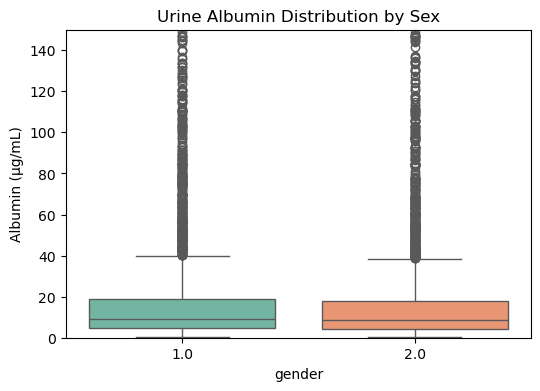

In [37]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender", y="albumin_urine_ug_mL", data=urine_alb_clean, palette="Set2")
plt.title("Urine Albumin Distribution by Sex")
plt.ylabel("Albumin (µg/mL)")
plt.ylim(0,150)

Separation and grouping the data by gender does not seem to change the median value of the urine albumin by much. 

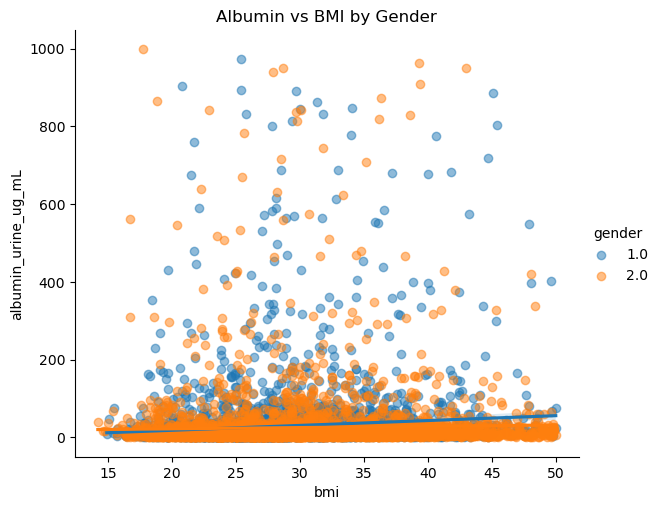

In [38]:
sns.lmplot(
    x="bmi",
    y="albumin_urine_ug_mL",
    hue="gender",
    data=urine_alb_clean,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha":0.5}  # optional: make points semi-transparent
)

plt.title("Albumin vs BMI by Gender")
plt.show()

When regression plot is created, however, it does seem like the male population may some positive correlation with BMI. Further statistical analysis was performed to evaluate the numerical values

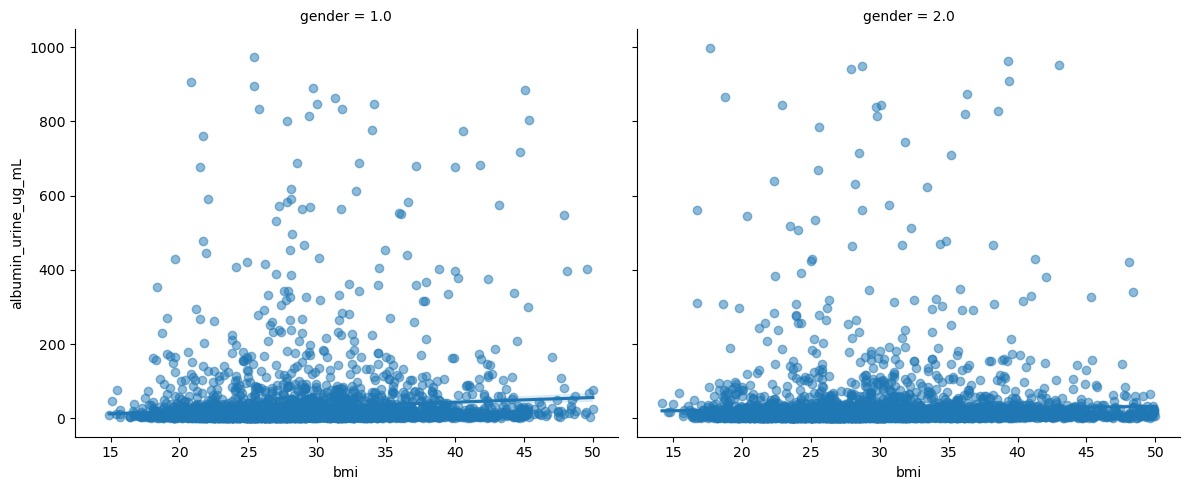

In [39]:
sns.lmplot(
    x="bmi",
    y="albumin_urine_ug_mL",
    col="gender",
    data=urine_alb_clean,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha":0.5}  # optional: make points semi-transparent
)
plt.show()

It appears that the slope of the regression line is slightly higher in the male population than the female population. The correlation will have to be calculated and observed to see whether that is also appreciated in the numeric form.

In [40]:
from scipy.stats import linregress

# Loop over genders
for sex in urine_alb_clean['gender'].unique():
    subset = urine_alb_clean[urine_alb_clean['gender'] == sex]
    slope, intercept, r_value, p_value, std_err = linregress(subset['bmi'], subset['albumin_urine_ug_mL'])
    print(f"{sex}: slope={slope:.4f}, intercept={intercept:.2f}, r={r_value:.4f}, p={p_value:.4g}")


2.0: slope=0.3255, intercept=15.58, r=0.0310, p=0.04263
1.0: slope=1.2521, intercept=-6.70, r=0.0901, p=7.434e-09


When looking at the slope, the raw value is higher in the male population but in the grand scheme of the lab values overall, even comparing to the standard deviation of the lab values, the slope is not impressive.

In [113]:
for gender, df_group in urine_alb_clean.groupby('gender'):
    corr = df_group[['bmi', 'albumin_urine_ug_mL']].corr().iloc[0, 1]
    print(f"Pearson correlation between BMI and urine albumin for {gender}: {corr:.3f}")

for gender, df_group in urine_alb_clean.groupby('gender'):
    corr = df_group[['bmi', 'albumin_urine_ug_mL']].corr(method="spearman").iloc[0, 1]
    print(f"Spearman's rank correlation between BMI and urine albumin for {gender}: {corr:.3f}")

Pearson correlation between BMI and urine albumin for 1.0: 0.090
Pearson correlation between BMI and urine albumin for 2.0: 0.031
Spearman's rank correlation between BMI and urine albumin for 1.0: 0.126
Spearman's rank correlation between BMI and urine albumin for 2.0: 0.116


In [41]:
# List non-numeric columns
non_numeric = urine_alb_clean.select_dtypes(exclude='number').columns
print(non_numeric)

# Or check types of all columns
print(urine_alb_clean.dtypes)

Index([], dtype='object')
participant_id         float64
gender                 float64
age_year               float64
bmi                    float64
albumin_urine_ug_mL    float64
race                   float64
dtype: object


The closer to the value of 0, the less there is a relationship between two values. Looking at the correlation table, it does appear that with urine albumin level overall does not seem to have a strong correlation with BMI (0.052). When the genders are separated, the correlation with albumin level seems to be _____.

### Log Transformation

In [43]:
urine_alb_clean['log_ualb'] = np.log(urine_alb_clean['albumin_urine_ug_mL'])

In [44]:
urine_alb_clean[['albumin_urine_ug_mL', 'log_ualb']].describe()

,albumin_urine_ug_mL,log_ualb
count,8372.000000,8372.000000
mean,27.356524,2.298367
std,78.809699,1.218858
min,0.210000,-1.560648
25%,4.600000,1.526056
50%,9.000000,2.197225
75%,18.400000,2.912351
max,998.000000,6.905753


In [45]:
urine_alb_clean['albumin_urine_ug_mL'].skew(), urine_alb_clean['log_ualb'].skew()

#greater the value, the more skewed the dataset is. After the natural log transformation, the data is no longer skewed

(np.float64(7.302292786598581), np.float64(0.6548154415712363))

In [46]:
urine_alb_clean['albumin_urine_ug_mL'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])


0.25      4.600
0.50      9.000
0.75     18.400
0.90     46.590
0.95     97.445
0.99    424.450
Name: albumin_urine_ug_mL, dtype: float64

In [47]:
urine_alb_clean['log_ualb'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.25    1.526056
0.50    2.197225
0.75    2.912351
0.90    3.841386
0.95    4.579288
0.99    6.050780
Name: log_ualb, dtype: float64

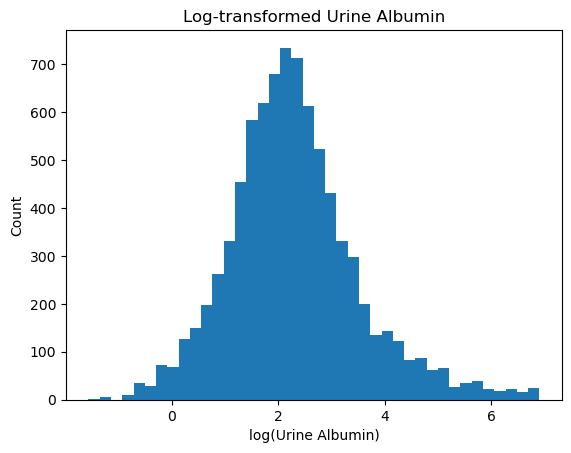

In [48]:
plt.hist(urine_alb_clean['log_ualb'].dropna(), bins=40)
plt.title("Log-transformed Urine Albumin")
plt.xlabel("log(Urine Albumin)")
plt.ylabel("Count")
plt.show()

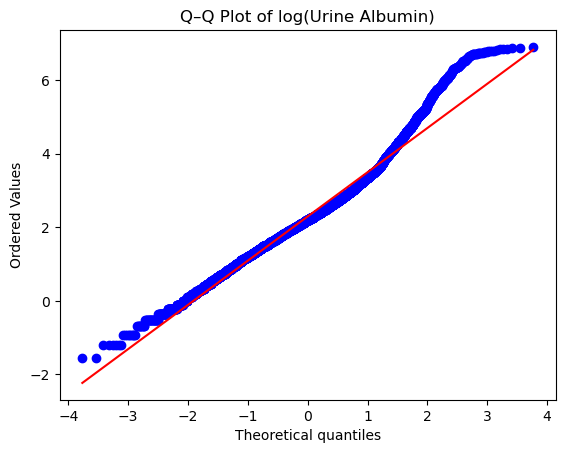

In [49]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(urine_alb_clean['log_ualb'], dist="norm", plot=plt)
plt.title("Q–Q Plot of log(Urine Albumin)")
plt.show()


In [50]:
urine_alb_clean[['bmi','log_ualb']].corr()

,bmi,log_ualb
bmi,1.000000,0.119131
log_ualb,0.119131,1.000000


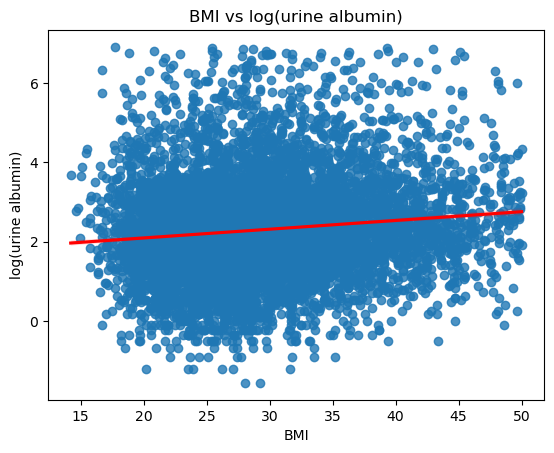

In [51]:
sns.regplot(x='bmi',y='log_ualb',data=urine_alb_clean,line_kws={"color": "red"})
plt.xlabel("BMI")
plt.ylabel("log(urine albumin)")
plt.title("BMI vs log(urine albumin)")
plt.show()

When looking at the overall BMI distribution, it seems that there is a weak correlation between the urine albumin levels and BMI. 

#### Log Transformation with Gender Stratification

In [52]:
albumin_log = urine_alb_clean.groupby("gender")["log_ualb"].describe()
print(albumin_log)

         count      mean       std       min       25%       50%       75%  \
gender                                                                       
1.0     4098.0  2.347444  1.230021 -1.560648  1.568616  2.219203  2.939162   
2.0     4274.0  2.251312  1.206328 -1.560648  1.481605  2.180401  2.895912   

             max  
gender            
1.0     6.881411  
2.0     6.905753  


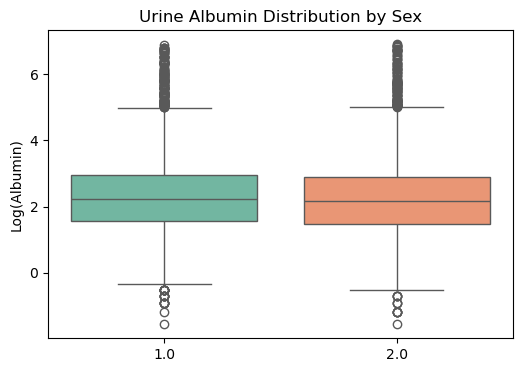

In [53]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender", y="log_ualb", data=urine_alb_clean, palette="Set2")
plt.title("Urine Albumin Distribution by Sex")
plt.xlabel("")
plt.ylabel("Log(Albumin)")
plt.show()

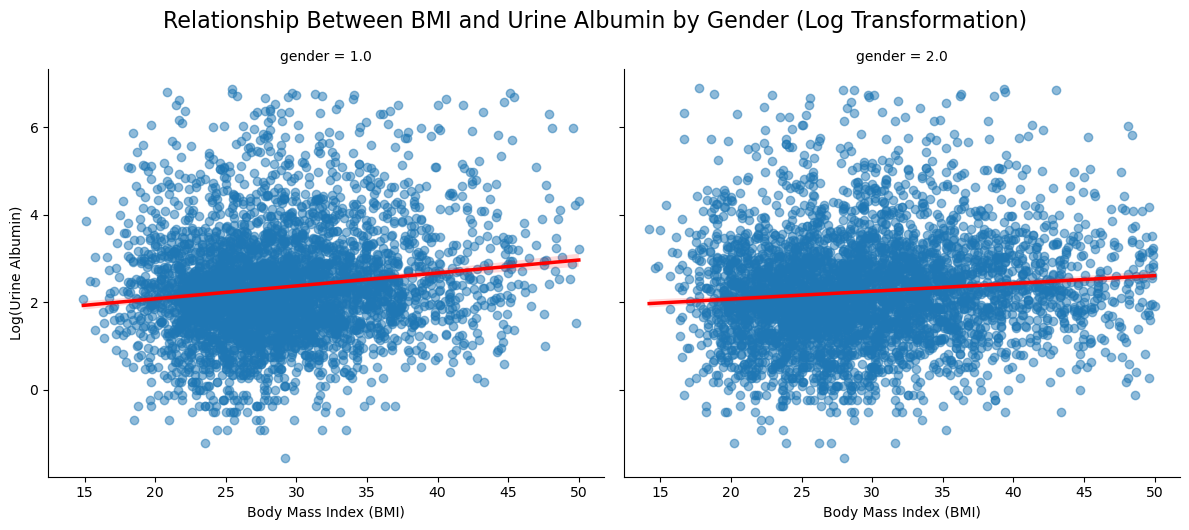

In [54]:
# Plot
g_log = sns.lmplot(
    x="bmi",
    y="log_ualb",
    col="gender",  # use the new label column
    data=urine_alb_clean,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red", "linewidth": 2.5}
)

# Add an overall title
g_log.fig.suptitle("Relationship Between BMI and Urine Albumin by Gender (Log Transformation)", fontsize=16, y=1.05)

# Add axis labels
g_log.set_axis_labels("Body Mass Index (BMI)", "Log(Urine Albumin)")

plt.show()

In [55]:
# Loop over genders
for sex in urine_alb_clean['gender'].unique():
    subset_log = urine_alb_clean[urine_alb_clean['gender'] == sex]
    slope, intercept, r_value, p_value, std_err = linregress(subset_log['bmi'], subset_log['log_ualb'])
    print(f"{sex}: slope={slope:.4f}, intercept={intercept:.2f}, r={r_value:.4f}, p={p_value:.4g}")

2.0: slope=0.0178, intercept=1.72, r=0.1049, p=6.11e-12
1.0: slope=0.0296, intercept=1.49, r=0.1435, p=2.612e-20


In [56]:
for gender, df_group in urine_alb_clean.groupby('gender'):
    corr_log = df_group[['bmi', 'log_ualb']].corr().iloc[0, 1]
    print(f"Pearson correlation between BMI and urine albumin for {gender}: {corr_log:.3f}")

Pearson correlation between BMI and urine albumin for 1.0: 0.144
Pearson correlation between BMI and urine albumin for 2.0: 0.105


In [57]:
import numpy as np
from math import atanh, sqrt

# Split groups
male = urine_alb_clean[urine_alb_clean['gender'] == 1]
female = urine_alb_clean[urine_alb_clean['gender'] == 2]

# Correlations
r_m = male['bmi'].corr(male['log_ualb'])
r_f = female['bmi'].corr(female['log_ualb'])

# Sample sizes
n_m = len(male)
n_f = len(female)

# Fisher r-to-z transformation
z_m = atanh(r_m)
z_f = atanh(r_f)

# Standard error
se = sqrt(1/(n_m - 3) + 1/(n_f - 3))

# z-test statistic
z = (z_m - z_f) / se

z

1.7931063687477833

In [58]:
from math import erf, sqrt

p_value = 2 * (1 - 0.5 * (1 + erf(abs(3.02) / sqrt(2))))
p_value


0.002527746855344626

It appears that the gender correlation seen between elevated urine albumin and BMI in the male obese cohort is stronger than from all BMI distribution cohort. However, the female cohort seems to have a stronger correlation when all BMI was taken into consideration.

## Urine Creatinine

Next, urine creatinine will be analyzed.

According to the laboratory test that was performed for the purposes of NHANES, the normal range for urine creatinine is as reported as follows:

 * Urine, adult male, first morning void: 40-278 mg/dL
 * Urine, adult female, first morning void: 29-226 mg/dL

(Mazzachi, et al. From the Roche reagent package insert for enzymatic creatinine.)

In [59]:
urine_cr = urine_cralb[['participant_id','gender','age_year','race','bmi',
'creatinine_urine_mg_dL']]

In [60]:
urine_cr.describe()

,participant_id,gender,age_year,race,bmi,creatinine_urine_mg_dL
count,8450.000000,8450.000000,8450.000000,8450.000000,8450.000000,8449.000000
mean,117114.195148,1.509349,49.318580,3.477870,29.372107,131.262635
std,4499.043056,0.499942,18.357545,1.581583,6.592660,86.976089
min,109266.000000,1.000000,18.000000,1.000000,14.200000,6.000000
25%,113233.750000,1.000000,33.000000,3.000000,24.600000,66.000000
50%,117081.500000,2.000000,50.000000,3.000000,28.500000,115.000000
75%,121052.750000,2.000000,64.000000,4.000000,33.300000,178.000000
max,124822.000000,2.000000,80.000000,7.000000,50.000000,739.000000


Because the urine creatinine normal range is varied by gender, the first step is to visualize how the spread differs by the gender. 

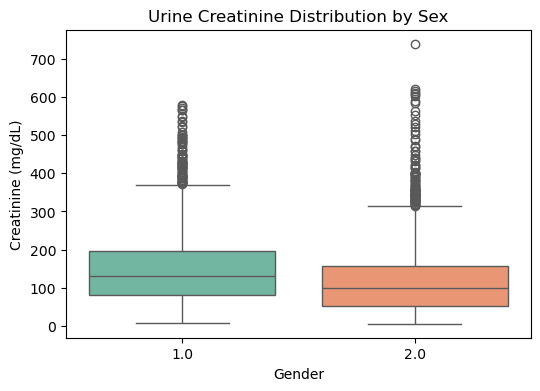

In [61]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender", y="creatinine_urine_mg_dL", data=urine_cr, palette="Set2")
plt.title("Urine Creatinine Distribution by Sex")
plt.ylabel("Creatinine (mg/dL)")
plt.xlabel("Gender")
plt.show()

There are some outliers but it apperas that most of these values fall within the normal range as specified above. The decision was made to keep all of these values, as the outliers do not seem to be skewing the data too much. 

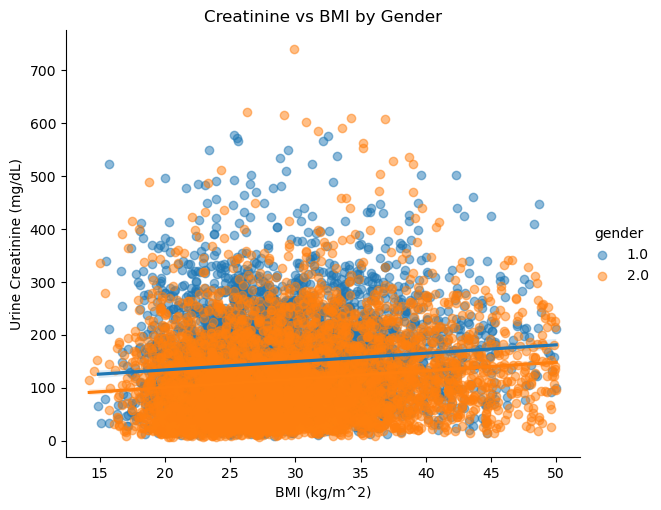

In [62]:
sns.lmplot(
    x="bmi",
    y="creatinine_urine_mg_dL",
    hue="gender",
    data=urine_cr,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha":0.5}  # optional: make points semi-transparent
)

plt.title("Creatinine vs BMI by Gender")
plt.ylabel("Urine Creatinine (mg/dL)")
plt.xlabel("BMI (kg/m^2)")
plt.show()

The linear regression line does not seem to have a strong slope or correlation. Male subjects seem to have a slightly stronger positive correlation compared to the female subjects but both lines' slopes seem to be minimal. 

The correlation seen between BMI and urine creatinine is 0.067, which means there is no correlation between those two values. 

### Log Transformation

In [64]:
urine_cr['log_ucr'] = np.log(urine_cr['creatinine_urine_mg_dL'])

In [65]:
urine_cr[['creatinine_urine_mg_dL', 'log_ucr']].describe()

,creatinine_urine_mg_dL,log_ucr
count,8449.000000,8449.000000
mean,131.262635,4.634802
std,86.976089,0.751552
min,6.000000,1.791759
25%,66.000000,4.189655
50%,115.000000,4.744932
75%,178.000000,5.181784
max,739.000000,6.605298


In [66]:
urine_cr['creatinine_urine_mg_dL'].skew(), urine_cr['log_ucr'].skew()

(np.float64(1.2572989759927748), np.float64(-0.6140994875695993))

In [67]:
urine_cr['creatinine_urine_mg_dL'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.25     66.0
0.50    115.0
0.75    178.0
0.90    247.0
0.95    289.0
0.99    413.0
Name: creatinine_urine_mg_dL, dtype: float64

In [68]:
urine_cr['log_ucr'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.25    4.189655
0.50    4.744932
0.75    5.181784
0.90    5.509388
0.95    5.666427
0.99    6.023448
Name: log_ucr, dtype: float64

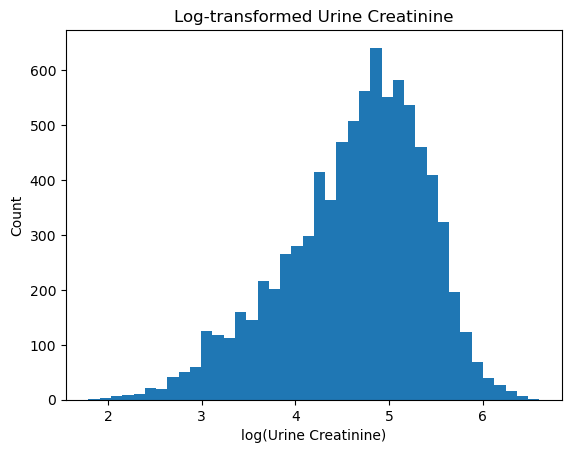

In [69]:
plt.hist(urine_cr['log_ucr'], bins=40)
plt.title("Log-transformed Urine Creatinine")
plt.xlabel("log(Urine Creatinine)")
plt.ylabel("Count")
plt.show()

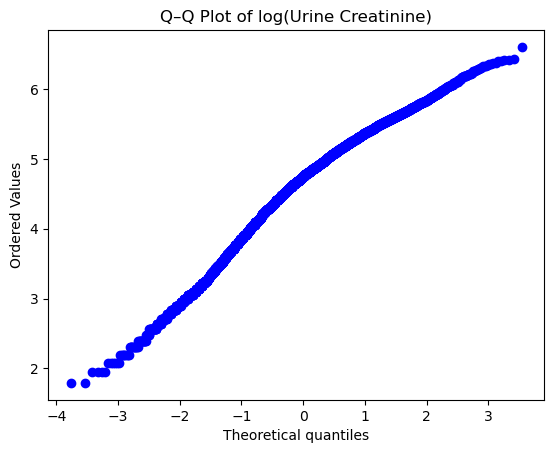

In [70]:
stats.probplot(urine_cr['log_ucr'], dist="norm", plot=plt)
plt.title("Q–Q Plot of log(Urine Creatinine)")
plt.show()

In [71]:
urine_cr[['bmi','log_ucr']].corr()

,bmi,log_ucr
bmi,1.000000,0.132913
log_ucr,0.132913,1.000000


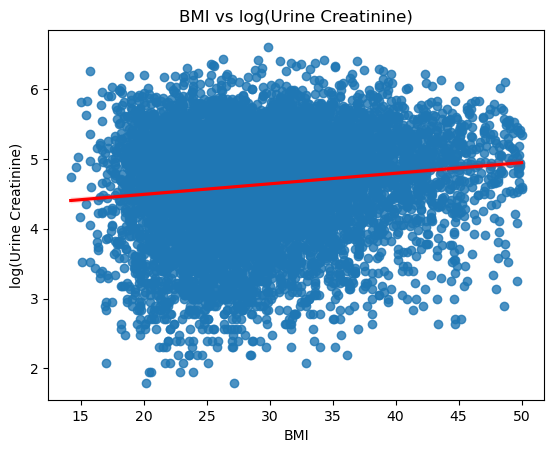

In [72]:
sns.regplot(x='bmi',y='log_ucr',data=urine_cr,line_kws={"color": "red"})
plt.xlabel("BMI")
plt.ylabel("log(Urine Creatinine)")
plt.title("BMI vs log(Urine Creatinine)")
plt.show()

**Log(Urine Creatinine) by Gender**

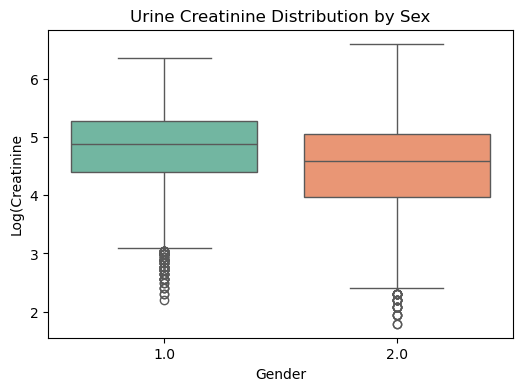

In [73]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender", y="log_ucr", data=urine_cr, palette="Set2")
plt.title("Urine Creatinine Distribution by Sex")
plt.ylabel("Log(Creatinine")
plt.xlabel("Gender")
plt.show()

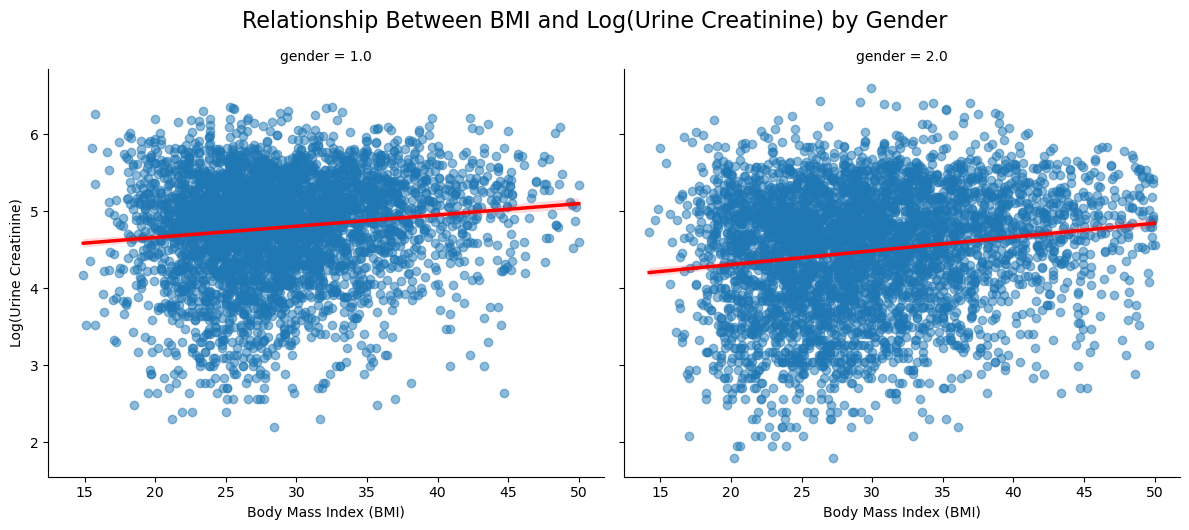

In [74]:
# Plot
g = sns.lmplot(
    x="bmi",
    y="log_ucr",
    col="gender",  # use the new label column
    data=urine_cr,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red", "linewidth": 2.5}
)

# Add an overall title
g.fig.suptitle("Relationship Between BMI and Log(Urine Creatinine) by Gender", fontsize=16, y=1.05)

# Add axis labels
g.set_axis_labels("Body Mass Index (BMI)", "Log(Urine Creatinine)")

plt.show()

In [75]:
for gender, df_group in urine_cr.groupby('gender'):
    corr_logcr = df_group[['bmi', 'log_ucr']].corr().iloc[0, 1]
    print(f"Correlation between BMI and urine creatinine for {gender}: {corr_logcr:.3f}")

Correlation between BMI and urine creatinine for 1.0: 0.128
Correlation between BMI and urine creatinine for 2.0: 0.163


There is a slight positive correlation between elevation of BMI and urine creatinine in the overall cohort. WHen stratified by gender, the correlation becomes stronger and it is stronger in the female cohort. With elevated BMI, urine creatinine also seems to elevate.

## Urine Iodine

Iodine is necessary for thyroid function which contribute to the metabolism in the body. Urine iodine secretion 

Median urinary iodine concentrations of 100–199 mcg/L in children and adults, 150–249 mcg/L in pregnant women and >100 mcg/L in lactating women indicate iodine intakes are adequate (https://ods.od.nih.gov/factsheets/Iodine-HealthProfessional/#:~:text=The%20iodine%2Dreplete%20healthy%20adult,intakes%20are%20adequate%20%5B3%5D.)

In [76]:
iodine = pd.read_csv('cleaned_u_iodine.csv')

In [77]:
urine_iodine = adults_filtered.merge(iodine, on='participant_id')

In [78]:
urine_iodine.shape

(2792, 19)

In [79]:
urine_iodine.head()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty,weight_kg,standing_height,standing_height_comment,bmi,upper_leg_cm,upper_arm_cm,arm_circumference_cm,waist_circ_cm,hip_circ_cm,bmi_category,urine_iodine,urine_iodine_comment
0,109266.0,2.0,29.0,6.0,5.0,3.0,5.00,97.1,160.2,NaN,37.8,40.8,34.7,35.8,117.9,126.1,Obese,50.6,0.0
1,109273.0,1.0,36.0,3.0,4.0,3.0,0.83,74.3,184.2,NaN,21.9,41.0,41.1,30.2,86.8,94.5,Normal,71.3,0.0
2,109274.0,1.0,68.0,7.0,4.0,3.0,1.20,103.7,185.3,NaN,30.2,44.0,47.0,32.0,109.6,107.8,Obese,265.3,0.0
3,109290.0,2.0,68.0,4.0,5.0,2.0,5.00,73.0,161.2,NaN,28.1,38.0,37.4,31.8,92.0,106.2,Overweight,122.4,0.0
4,109295.0,2.0,54.0,1.0,1.0,1.0,5.00,61.7,157.4,NaN,24.9,34.7,38.0,29.0,90.5,101.0,Normal,198.0,0.0


In [80]:
urine_iodine = urine_iodine[['participant_id','race','gender','bmi','urine_iodine']]

In [81]:
urine_iodine.head()

,participant_id,race,gender,bmi,urine_iodine
0,109266.0,6.0,2.0,37.8,50.6
1,109273.0,3.0,1.0,21.9,71.3
2,109274.0,7.0,1.0,30.2,265.3
3,109290.0,4.0,2.0,28.1,122.4
4,109295.0,1.0,2.0,24.9,198.0


In [82]:
urine_iodine.describe()

,participant_id,race,gender,bmi,urine_iodine
count,2792.000000,2792.000000,2792.000000,2792.000000,2792.000000
mean,117005.088825,3.503223,1.506805,29.252937,237.219269
std,4470.060993,1.600113,0.500043,6.580767,820.541696
min,109266.000000,1.000000,1.000000,14.600000,2.600000
25%,113201.750000,3.000000,1.000000,24.500000,70.275000
50%,116991.000000,3.000000,2.000000,28.300000,123.000000
75%,120848.000000,4.000000,2.000000,33.200000,227.750000
max,124821.000000,7.000000,2.000000,50.000000,23637.300000


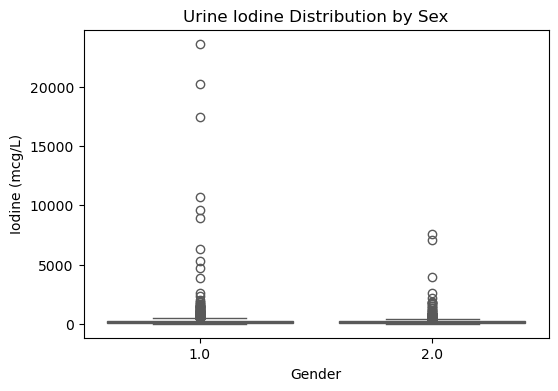

In [83]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender", y="urine_iodine", data=urine_iodine, palette="Set2")
plt.title("Urine Iodine Distribution by Sex")
plt.ylabel("Iodine (mcg/L)")
plt.xlabel("Gender")
plt.show()

The urine iodine unit is mcg/L. The value that is in the 10,000 seems to be way too excessive. The typical concern with urine iodine is reduced output which equates to inadequate intake to support normal physiological functions. However, the upper range in this cohort is in the 10,000 mcg/L which seems to be excessive. Much like the albumin and creatinine, the outliers should be removed for a proper analysis. From the descriptive statistics and the visualization, having a cutoff of 2500 mcg/L appears to be adequate. 

In [84]:
# Define your threshold
threshold = 2500  

# Count how many subjects exceed the threshold
extreme_count = (urine_iodine['urine_iodine'] >= threshold).sum()

# Total number of subjects
total_count = urine_iodine['urine_iodine'].notna().sum()

# Percentage
extreme_percent = (extreme_count / total_count) * 100

print(f"Subjects with extreme iodine values (≥ {threshold} µg/mL): {extreme_count}")
print(f"Total subjects with iodine values: {total_count}")
print(f"Percentage extreme: {extreme_percent:.2f}%")

Subjects with extreme iodine values (≥ 2500 µg/mL): 15
Total subjects with iodine values: 2792
Percentage extreme: 0.54%


In [85]:
# Keep only subjects below threshold
urine_iodine_clean = urine_iodine[urine_iodine['urine_iodine'] < threshold].copy()

print(f"Original: {urine_iodine.shape[0]} rows")
print(f"After removing extreme albumin values: {urine_iodine_clean.shape[0]} rows")


Original: 2792 rows
After removing extreme albumin values: 2777 rows


In [86]:
urine_iodine_clean.describe()

,participant_id,race,gender,bmi,urine_iodine
count,2777.000000,2777.000000,2777.000000,2777.000000,2777.000000
mean,116998.541232,3.504141,1.508102,29.250918,190.069463
std,4465.070774,1.602884,0.500024,6.580831,222.315656
min,109266.000000,1.000000,1.000000,14.600000,2.600000
25%,113202.000000,3.000000,1.000000,24.400000,70.100000
50%,116969.000000,3.000000,2.000000,28.300000,122.300000
75%,120847.000000,4.000000,2.000000,33.200000,224.000000
max,124821.000000,7.000000,2.000000,50.000000,2337.000000


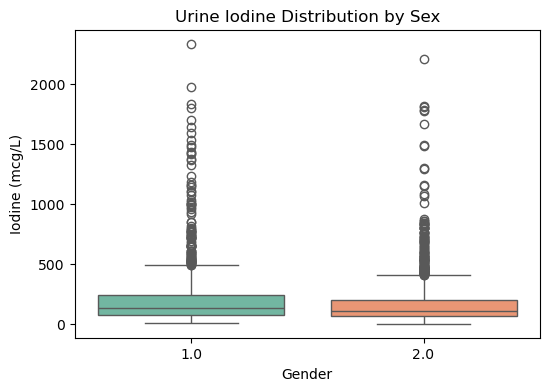

In [87]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender", y="urine_iodine", data=urine_iodine_clean, palette="Set2")
plt.title("Urine Iodine Distribution by Sex")
plt.ylabel("Iodine (mcg/L)")
plt.xlabel("Gender")
plt.show()

After removing the values that are greather than or equal to 2500, the plot still shows quite a bit of variance and outliers. The decision was then made to limit the upper value of iodine to 1000 mcg/L.

In [88]:
# Define your threshold
threshold = 1000 

# Count how many subjects exceed the threshold
extreme_count = (urine_iodine_clean['urine_iodine'] >= threshold).sum()

# Total number of subjects
total_count = urine_iodine_clean['urine_iodine'].notna().sum()

# Percentage
extreme_percent = (extreme_count / total_count) * 100

print(f"Subjects with extreme iodine values (≥ {threshold} µg/mL): {extreme_count}")
print(f"Total subjects with iodine values: {total_count}")
print(f"Percentage extreme: {extreme_percent:.2f}%")

Subjects with extreme iodine values (≥ 1000 µg/mL): 44
Total subjects with iodine values: 2777
Percentage extreme: 1.58%


In [89]:
# Keep only subjects below threshold
urine_iodine_clean = urine_iodine[urine_iodine['urine_iodine'] < threshold].copy()

print(f"Original: {urine_iodine.shape[0]} rows")
print(f"After removing extreme albumin values: {urine_iodine_clean.shape[0]} rows")

Original: 2792 rows
After removing extreme albumin values: 2733 rows


In [90]:
urine_iodine_clean.describe()

,participant_id,race,gender,bmi,urine_iodine
count,2733.000000,2733.000000,2733.000000,2733.000000,2733.000000
mean,116983.804610,3.494694,1.510794,29.256531,170.425210
std,4464.038014,1.600143,0.499975,6.570692,155.054036
min,109266.000000,1.000000,1.000000,14.600000,2.600000
25%,113199.000000,3.000000,1.000000,24.500000,69.100000
50%,116964.000000,3.000000,2.000000,28.400000,120.300000
75%,120828.000000,4.000000,2.000000,33.200000,215.500000
max,124821.000000,7.000000,2.000000,50.000000,991.600000


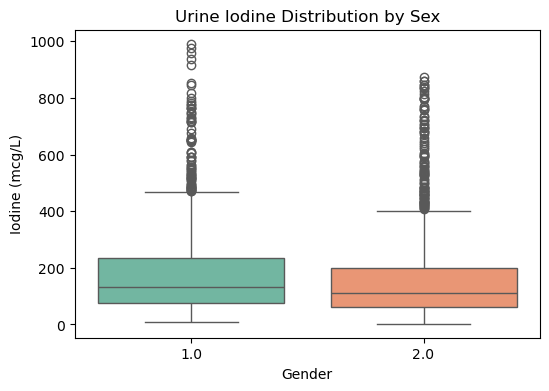

In [91]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender", y="urine_iodine", data=urine_iodine_clean, palette="Set2")
plt.title("Urine Iodine Distribution by Sex")
plt.ylabel("Iodine (mcg/L)")
plt.xlabel("Gender")
plt.show()

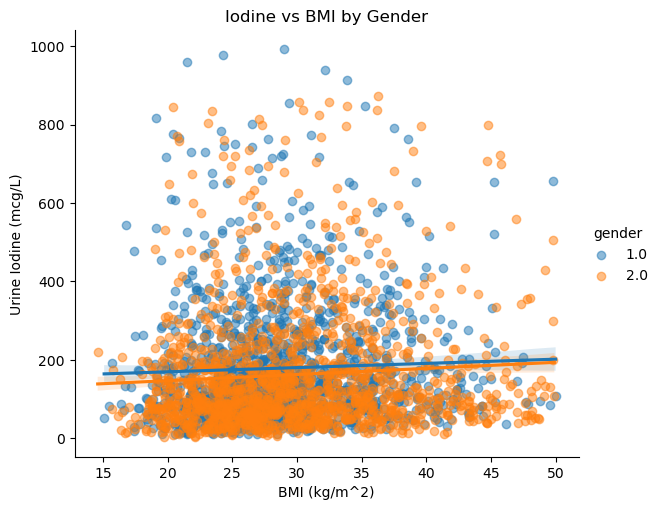

In [92]:
sns.lmplot(
    x="bmi",
    y="urine_iodine",
    hue="gender",
    data=urine_iodine_clean,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha":0.5}  # optional: make points semi-transparent
)

plt.title("Iodine vs BMI by Gender")
plt.ylabel("Urine Iodine (mcg/L)")
plt.xlabel("BMI (kg/m^2)")
plt.show()

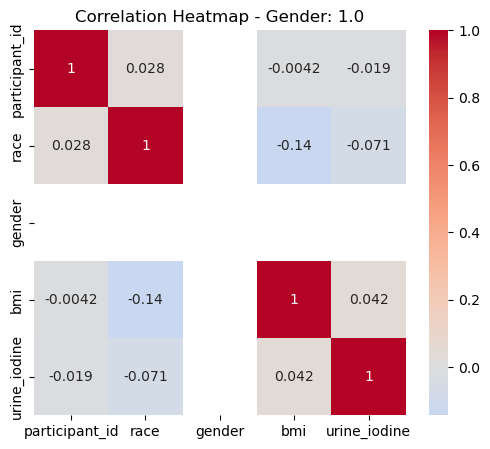

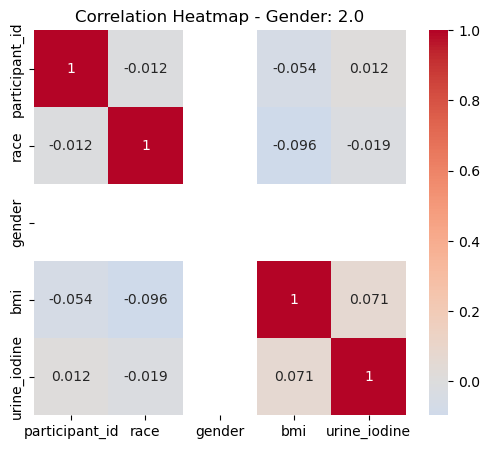

In [93]:
for gender, df_group in urine_iodine_clean.groupby('gender'):
    # compute correlation within this gender group
    corr_matrix = df_group.corr()

    plt.figure(figsize=(6,5))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title(f'Correlation Heatmap - Gender: {gender}')
    plt.show()

There is no strong correlation between BMI and urine iodine levels. The regression plot shows perhaps slight negative correlation but the slope does not seem to be significant. The correlation heatmap shows that there is no substantial correlation between BMI and urine iodine, although the direction of the correlation is negative. 

#### Log Transformation of Urine Iodine

In [94]:
urine_iodine_clean['log_uio'] = np.log(urine_iodine_clean['urine_iodine'])

In [95]:
urine_iodine_clean[['urine_iodine', 'log_uio']].describe()

,urine_iodine,log_uio
count,2733.000000,2733.000000
mean,170.425210,4.782510
std,155.054036,0.869887
min,2.600000,0.955511
25%,69.100000,4.235555
50%,120.300000,4.789989
75%,215.500000,5.372961
max,991.600000,6.899320


In [96]:
urine_iodine_clean['urine_iodine'].skew(), urine_iodine_clean['log_uio'].skew()

(np.float64(2.0344630900892287), np.float64(-0.20307617980099787))

In [97]:
urine_iodine_clean['urine_iodine'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.25     69.100
0.50    120.300
0.75    215.500
0.90    367.380
0.95    488.180
0.99    773.012
Name: urine_iodine, dtype: float64

In [98]:
urine_iodine_clean['log_uio'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.25    4.235555
0.50    4.789989
0.75    5.372961
0.90    5.906397
0.95    6.190681
0.99    6.650292
Name: log_uio, dtype: float64

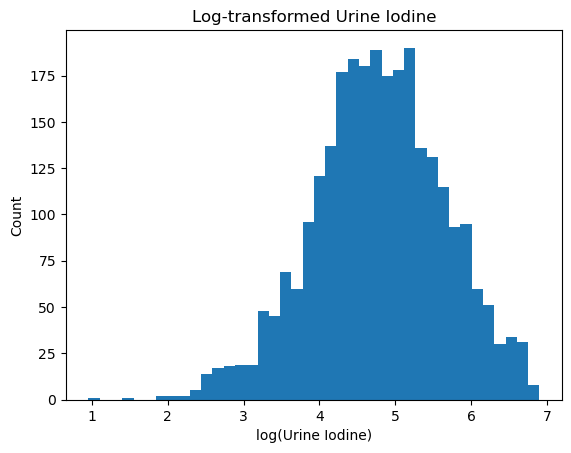

In [99]:
plt.hist(urine_iodine_clean['log_uio'], bins=40)
plt.title("Log-transformed Urine Iodine")
plt.xlabel("log(Urine Iodine)")
plt.ylabel("Count")
plt.show()

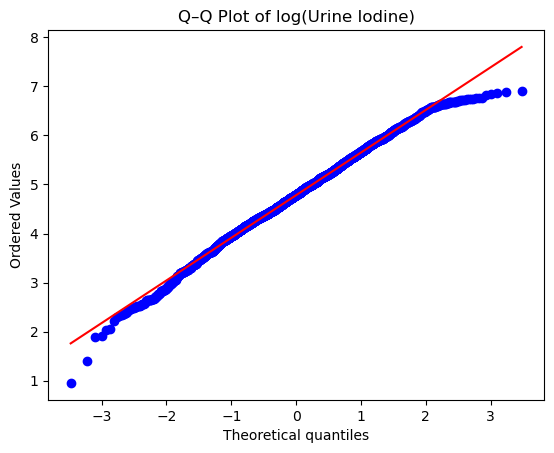

In [100]:
stats.probplot(urine_iodine_clean['log_uio'], dist="norm", plot=plt)
plt.title("Q–Q Plot of log(Urine Iodine)")
plt.show()

In [101]:
urine_iodine_clean[['bmi','log_uio']].corr()

,bmi,log_uio
bmi,1.000000,0.089681
log_uio,0.089681,1.000000


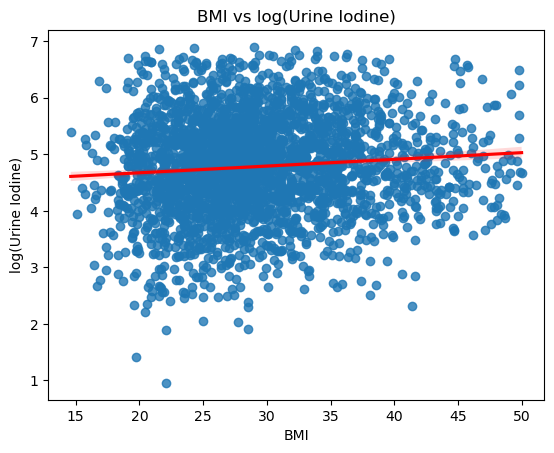

In [102]:
sns.regplot(x='bmi',y='log_uio',data=urine_iodine_clean,line_kws={"color": "red"})
plt.xlabel("BMI")
plt.ylabel("log(Urine Iodine)")
plt.title("BMI vs log(Urine Iodine)")
plt.show()

There is no correlation between urine iodine and BMI.

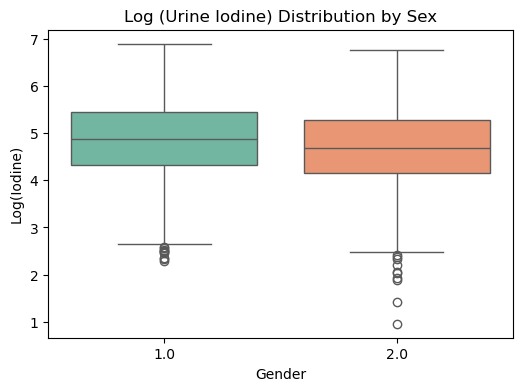

In [103]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender", y="log_uio", data=urine_iodine_clean, palette="Set2")
plt.title("Log (Urine Iodine) Distribution by Sex")
plt.ylabel("Log(Iodine)")
plt.xlabel("Gender")
plt.show()

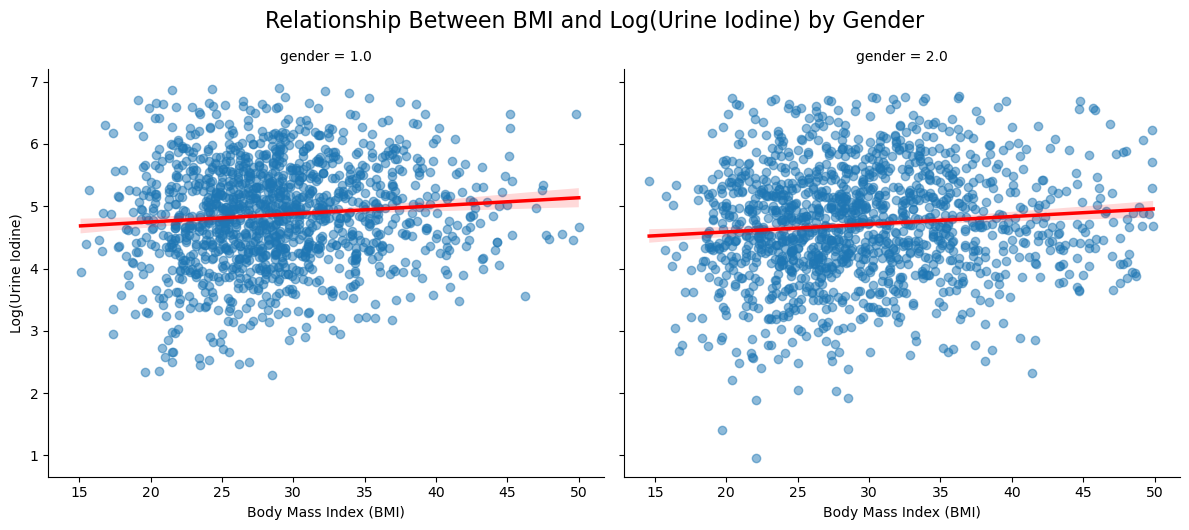

In [104]:
# Plot
g = sns.lmplot(
    x="bmi",
    y="log_uio",
    col="gender",  # use the new label column
    data=urine_iodine_clean,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red", "linewidth": 2.5}
)

# Add an overall title
g.fig.suptitle("Relationship Between BMI and Log(Urine Iodine) by Gender", fontsize=16, y=1.05)

# Add axis labels
g.set_axis_labels("Body Mass Index (BMI)", "Log(Urine Iodine)")

plt.show()

In [105]:
for gender, df_group in urine_iodine_clean.groupby('gender'):
    corr_logio = df_group[['bmi', 'log_uio']].corr().iloc[0, 1]
    print(f"Correlation between BMI and urine iodine for {gender}: {corr_logio:.3f}")

Correlation between BMI and urine iodine for 1.0: 0.093
Correlation between BMI and urine iodine for 2.0: 0.097


Even with the gender stratification, there is no correlation between the urine iodine excretion and BMI.

### Multivariable Regression

In [106]:
alb_cols   = urine_alb_clean[['participant_id', 'log_ualb']]
creat_cols = urine_cr[['participant_id', 'log_ucr']]
io_cols = urine_iodine_clean[['participant_id', 'log_uio']]
bmi_cols   = adults_filtered[['participant_id', 'bmi', 'gender']]

In [107]:
df_mult = alb_cols.merge(creat_cols, on='participant_id') \
             .merge(io_cols, on='participant_id') \
             .merge(bmi_cols, on='participant_id')

In [108]:
df_mult.describe

<bound method NDFrame.describe of       participant_id  log_ualb   log_ucr   log_uio   bmi  gender
0           109266.0  1.704748  3.583519  3.923952  37.8     2.0
1           109273.0  1.589235  4.795791  4.266896  21.9     1.0
2           109274.0  2.549445  4.787492  5.580861  30.2     1.0
3           109290.0  3.109061  5.605802  4.807294  28.1     2.0
4           109295.0  2.564949  3.912023  5.288267  24.9     2.0
...              ...       ...       ...       ...   ...     ...
2702        124798.0  1.974081  5.099866  4.151040  26.0     1.0
2703        124799.0  5.728475  4.564348  4.782479  23.9     2.0
2704        124809.0  2.509599  5.411646  4.667206  27.1     2.0
2705        124812.0  2.970414  4.234107  4.760463  28.7     2.0
2706        124821.0  1.808289  5.252273  5.400423  25.5     1.0

[2707 rows x 6 columns]>

In [109]:
import statsmodels.api as sm

y = df_mult['bmi']

X = df_mult[['log_ualb', 'log_ucr', 'log_uio']]  
X = sm.add_constant(X)  # adds intercept

ImportError: cannot import name '_lazywhere' from 'scipy._lib._util' (C:\Users\Rachel\anaconda3\Lib\site-packages\scipy\_lib\_util.py)

In [ ]:
model = sm.OLS(y, X).fit()
model.summary()

### Conclusion

Based on the analysis performed with NHANES urine dataset, there was no substantial correlation between the urine creatinine, albumin, or iodine with BMI. There were slight difference between genders in the urine albumin and urine iodine but neither were significant enough to make associations with. 

These findings are reasonable since the urine labs are more related to kidney function and overall nutritional status of a person. Obesity is the pathology caused by metabolic imbalance. 

The next analysis that should be peformed should be comparing how these values differ between normal BMI popultion and obese BMI population. 

Urine albumin and urine creatinine both show small but statistically significant positive associations with BMI.

Another urine lab (log_uio) does not predict BMI.

Together, all urine variables explain only ~2.6% of BMI variation, meaning urine biomarkers are not strong predictors of body mass.

The effects are real but not clinically large.